# 02 — Кредит Scorecard (WoE/IV + Logistic Regression)

**Scorecard гэж юу вэ?** Банк/ББСБ-д хамгийн өргөн хэрэглэгддэг, **ил тод**
эрсдэлийн модель. Хувьсагч бүрийг хэсэг (bin)-д хувааж, хэсэг бүрд **WoE
(Weight of Evidence)** утга оноож, дараа нь logistic regression-аар оноо
гаргадаг. Үр дүн нь "хүн бүр уншиж ойлгох" хүснэгт — аль шинж чанар хэдэн оноо
нэмж/хасч байгааг шууд харуулна.

**Яагаад энэ арга?** Зохицуулагч/аудитад тайлбарлахад хялбар, тогтвортой,
дутуу утгыг тусдаа bin болгон зохицуулдаг.

**Гаралт:** харилцагч бүрд 350–850 муж дахь оноо (өндөр = бага эрсдэл) ба
бүрэн scorecard хүснэгт (`models/scorecard_table_*.csv`).

**Хэмжүүр:** AUC, Gini, KS. Train ба Test-ийг харьцуулж overfit-ийг шалгана.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os
import warnings
warnings.filterwarnings('ignore')

from optbinning import BinningProcess, Scorecard
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import config, features, metrics, feature_selection as fs

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
os.makedirs(config.MODEL_DIR, exist_ok=True)

df = config.load_data()
df = features.engineer_features(df)
print(f"Loaded + engineered: {df.shape}")

[load_data] neither хасав: 57,127 → 39,242 (17,885 мөр хасагдсан)
Loaded + engineered: (39242, 107)


## 1. Feature тохиргоо

Бүх боломжит feature-ийг ашиглана. Газарзүйн байршлыг high-cardinality `city_name` (75 анги)-ийн оронд **`zone` (14 анги: 5 хөдөөгийн бүс + УБ 9 дүүрэг)** категори хувьсагчаар төлөөлүүлнэ. `BinningProcess` нь категори `zone`-г WoE-ээр зохицуулна.

(Энэ нь БҮХ боломжит feature. Дараагийн алхамд IV+корреляцаар цөөлнө.)

In [2]:
TARGETS = config.TARGETS
FEATURE_COLS = config.feature_columns(df)
CATEGORICAL_VARS = [c for c in config.CATEGORICAL_VARS if c in FEATURE_COLS]
NUMERIC_VARS = [c for c in FEATURE_COLS if c not in CATEGORICAL_VARS]

print(f"Total features: {len(FEATURE_COLS)}")
print(f"  Numeric:     {len(NUMERIC_VARS)}")
print(f"  Categorical: {len(CATEGORICAL_VARS)}")

Total features: 101
  Numeric:     100
  Categorical: 1


## 2. Хувьсагч сонголт (IV + корреляцийн шүүлт)

~100 хувьсагчийг **бодитоор цөөлж** дараа нь модель сургана:
1. **IV шүүлт** — `IV < 0.02` (ялгах чадваргүй) хувьсагчийг хасна.
2. **Корреляцийн шүүлт** — `|r| > 0.75` хос байвал IV бага талыг хасна
   (multicollinearity бууруулна).

Шүүлтийг ЗӨВХӨН `train` дээр тооцоолно (leakage-гүй). Доорх heatmap нь
цөөлөхөөс өмнө/хойш корреляц хэрхэн цэгцэрснийг харуулна.

Бүх feature: 101  →  IV+корреляц шүүлтийн дараа: 44


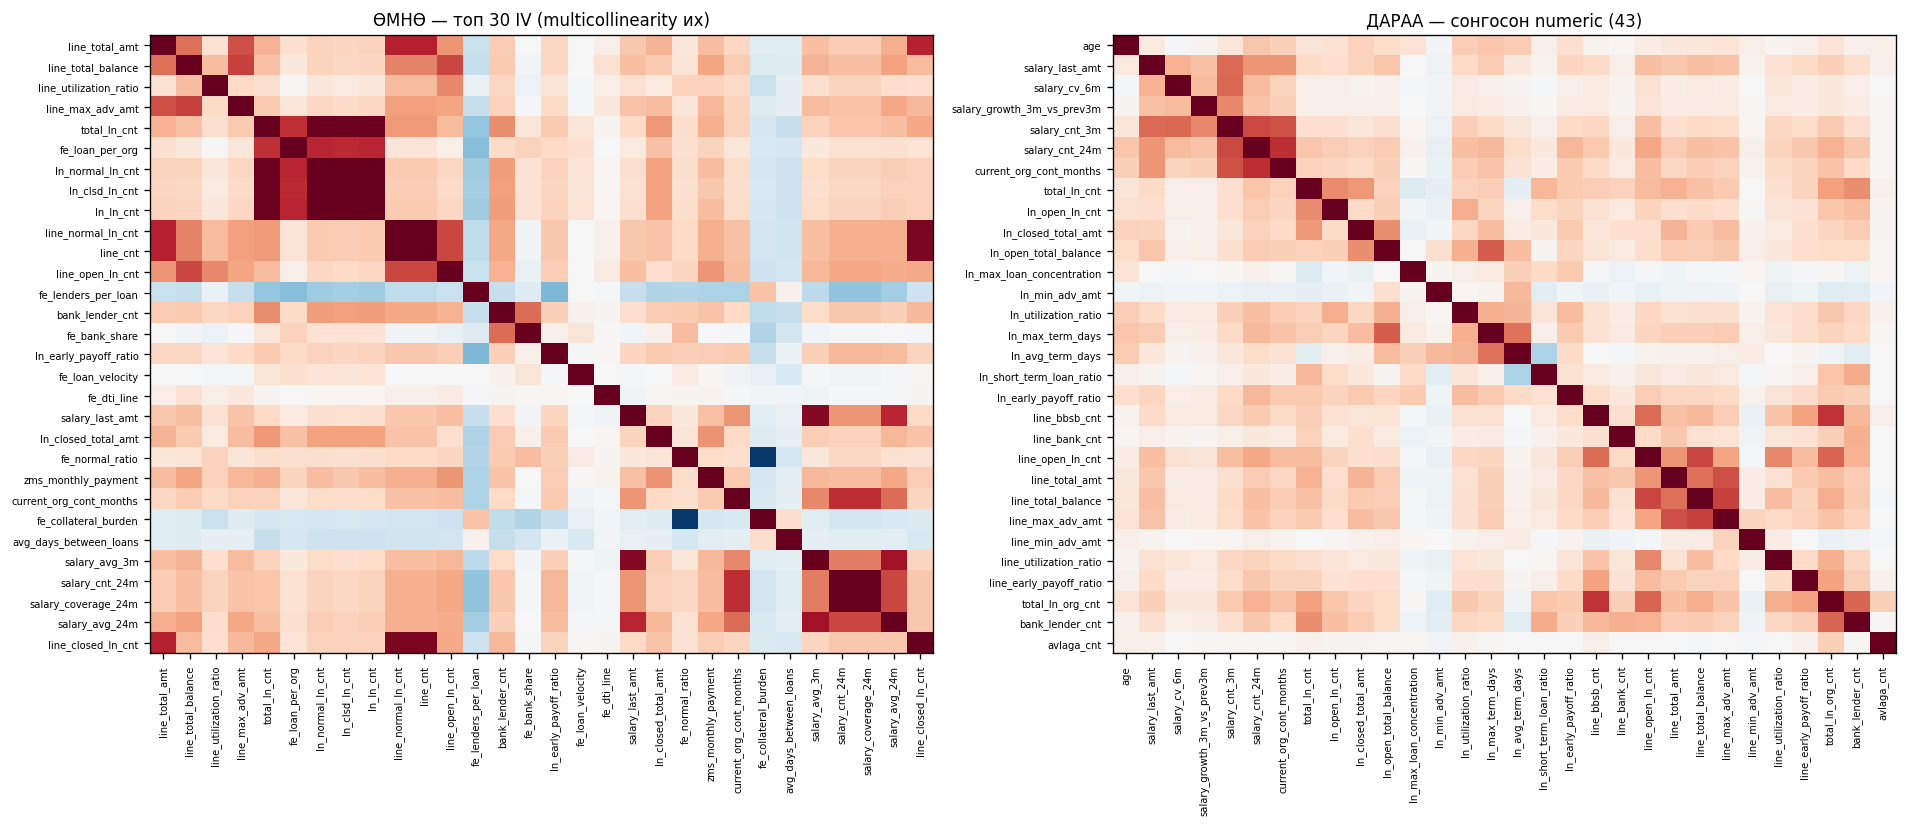

Сонгосон → Numeric: 43  Categorical: 1


In [3]:
import feature_selection as fs
import pandas as pd

PRIMARY = config.PRIMARY_TARGET
IS_TEST = config.make_split(df)
df_tr = df[~IS_TEST]
feat_all = config.feature_columns(df)

sel, iv = fs.select_features(
    df_tr, feat_all, PRIMARY,
    categorical=tuple(config.CATEGORICAL_VARS),
    iv_threshold=0.02, corr_threshold=0.75)
print(f"Бүх feature: {len(feat_all)}  →  IV+корреляц шүүлтийн дараа: {len(sel)}")

iv_s = pd.Series(iv).sort_values(ascending=False)
before = [c for c in iv_s.head(30).index if c in df_tr.columns]
after_num = [c for c in sel if c in df_tr.columns and df_tr[c].dtype.kind in 'fi']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
metrics.plot_corr_heatmap(df_tr, before, axes[0], 'ӨМНӨ — топ 30 IV (multicollinearity их)')
metrics.plot_corr_heatmap(df_tr, after_num[:30], axes[1], f'ДАРАА — сонгосон numeric ({len(after_num)})')
plt.tight_layout(); plt.show()

# Цаашид ЭНЭ сонгосон олонлогоор scorecard сургана
FEATURE_COLS = sel
CATEGORICAL_VARS = [c for c in config.CATEGORICAL_VARS if c in FEATURE_COLS]
NUMERIC_VARS = [c for c in FEATURE_COLS if c not in CATEGORICAL_VARS]
print(f"Сонгосон → Numeric: {len(NUMERIC_VARS)}  Categorical: {len(CATEGORICAL_VARS)}")

### Сонгогдсон хувьсагчийн жагсаалт (IV-тэй)

Цөөлж сонгосон хувьсагч бүрийг IV (ялгах чадвар), хүч, төрлөөр нь харуулна.

In [4]:
sel_tbl = pd.DataFrame({'feature': list(FEATURE_COLS)})
sel_tbl['IV'] = sel_tbl['feature'].map(lambda c: round(iv.get(c, float('nan')), 3))
sel_tbl['хүч'] = sel_tbl['IV'].map(lambda v: fs.iv_label(v) if v == v else '— (категори)')
sel_tbl['төрөл'] = sel_tbl['feature'].map(
    lambda c: 'flag' if c in ('has_hur', 'has_zms')
    else ('категори' if c in config.CATEGORICAL_VARS
          else ('fe (шинэ)' if c.startswith('fe_') else 'түүхий')))
sel_tbl = sel_tbl.sort_values('IV', ascending=False, na_position='last').reset_index(drop=True)
sel_tbl.index = sel_tbl.index + 1
print(f"СОНГОГДСОН {len(sel_tbl)} ХУВЬСАГЧ (IV-ээр эрэмбэлсэн):")
print(sel_tbl.to_string())

СОНГОГДСОН 44 ХУВЬСАГЧ (IV-ээр эрэмбэлсэн):
                       feature     IV           хүч      төрөл
1               line_total_amt  0.153        Medium     түүхий
2           line_total_balance  0.145        Medium     түүхий
3       line_utilization_ratio  0.140        Medium     түүхий
4             line_max_adv_amt  0.135        Medium     түүхий
5                 total_ln_cnt  0.132        Medium     түүхий
6              fe_loan_per_org  0.121        Medium  fe (шинэ)
7             line_open_ln_cnt  0.103        Medium     түүхий
8          fe_lenders_per_loan  0.087          Weak  fe (шинэ)
9              bank_lender_cnt  0.087          Weak     түүхий
10       ln_early_payoff_ratio  0.086          Weak     түүхий
11               fe_bank_share  0.086          Weak  fe (шинэ)
12            fe_loan_velocity  0.085          Weak  fe (шинэ)
13             salary_last_amt  0.084          Weak     түүхий
14                 fe_dti_line  0.084          Weak  fe (шинэ)
15         

## 3. Scorecard сургах (сонгосон хувьсагчаар) (таргет бүрд нэг)

`BinningProcess` нь feature тус бүрийн IV-г максимумчлах WoE bin олно:
- `max_n_bins=8`, `min_bin_size=0.03`, `max_pvalue=0.05` (chi-squared merge)
- Дутуу утга → тусдаа "Missing" bin
- Logistic Regression-ийн коэффициентоос bin тус бүрийн оноо гарна.

Алхамууд: (1) `BinningProcess` хувьсагч бүрийг оновчтой bin-д хуваана (монотон хандлагатай), (2) WoE хувиргалт, (3) `class_weight='balanced'`-тэй logistic regression, (4) оноог 350–850 руу min-max scaling. Дутуу утга автоматаар тусдаа bin болж үлддэг тул цалин ~52% дутуу байх нь асуудалгүй.

In [5]:
def safe_name(t):
    return t.replace('+','plus').replace(' ','_')

# НЭГ удаагийн нийтлэг хуваалт — target-аас үл хамааран ИЖИЛ мөрүүд test-д орно
IS_TEST = config.make_split(df)
results = {}

for target in TARGETS:
    print(f"\n{'='*60}")
    print(f"TARGET: {target}  (bad rate: {df[target].mean()*100:.1f}%)")
    print('='*60)

    X = df[FEATURE_COLS].copy()
    if 'zone' in X.columns:
        X['zone'] = X['zone'].astype(str)
    y = df[target].values

    X_train, X_test = X[~IS_TEST], X[IS_TEST]
    y_train, y_test = y[~IS_TEST], y[IS_TEST]
    print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

    bp = BinningProcess(
        variable_names=FEATURE_COLS,
        categorical_variables=CATEGORICAL_VARS,
        max_n_prebins=20, min_prebin_size=0.05,
        min_n_bins=2, max_n_bins=8, min_bin_size=0.03,
        max_pvalue=0.05, max_pvalue_policy='consecutive',
        binning_fit_params={'monotonic_trend': 'auto_asc_desc'})

    clf = LogisticRegression(solver='lbfgs', max_iter=1000, C=0.1,
                             class_weight='balanced', random_state=config.SEED)

    scorecard = Scorecard(
        binning_process=bp, estimator=clf, scaling_method='min_max',
        scaling_method_params={'min': config.SCORE_MIN, 'max': config.SCORE_MAX},
        reverse_scorecard=False)
    scorecard.fit(X_train, y_train)

    proba_train = scorecard.predict_proba(X_train)[:, 1]
    proba_test  = scorecard.predict_proba(X_test)[:, 1]
    scores_train = scorecard.score(X_train)
    scores_test  = scorecard.score(X_test)

    m_tr = metrics.eval_metrics(y_train, proba_train, f'{target} train')
    m_te = metrics.eval_metrics(y_test,  proba_test,  f'{target} test')

    results[target] = dict(
        scorecard=scorecard, y_train=y_train, y_test=y_test,
        proba_train=proba_train, proba_test=proba_test,
        scores_train=scores_train, scores_test=scores_test,
        train_metrics=m_tr, test_metrics=m_te)

    path = os.path.join(config.MODEL_DIR, f'scorecard_{safe_name(target)}.joblib')
    joblib.dump(scorecard, path)
    print(f"Saved: {path}")


TARGET: 30  (bad rate: 12.9%)
Train: 31,393  Test: 7,849


30 train                        AUC=0.6773  Gini=0.3546  KS=0.2607
30 test                         AUC=0.6625  Gini=0.3250  KS=0.2457
Saved: ../models/scorecard_30.joblib

TARGET: before_first_close_30+  (bad rate: 4.2%)
Train: 31,393  Test: 7,849


before_first_close_30+ train    AUC=0.6705  Gini=0.3410  KS=0.2449
before_first_close_30+ test     AUC=0.6324  Gini=0.2647  KS=0.2120
Saved: ../models/scorecard_before_first_close_30plus.joblib


## 3. Гүйцэтгэлийн нэгтгэл

Train ба Test хоёрын зөрүү бага байвал модель overfit хийгээгүй гэсэн үг.

In [6]:
rows = []
for target, res in results.items():
    rows.append({
        'Target': target,
        'Train AUC': round(res['train_metrics']['auc'], 4),
        'Test AUC':  round(res['test_metrics']['auc'], 4),
        'Train Gini':round(res['train_metrics']['gini'], 4),
        'Test Gini': round(res['test_metrics']['gini'], 4),
        'Test KS':   round(res['test_metrics']['ks'], 4)})
summary_df = pd.DataFrame(rows).set_index('Target')
summary_df

,Train AUC,Test AUC,Train Gini,Test Gini,Test KS
Target,,,,,
30,0.6773,0.6625,0.3546,0.3250,0.2457
before_first_close_30+,0.6705,0.6324,0.3410,0.2647,0.2120


## 4. ROC муруй

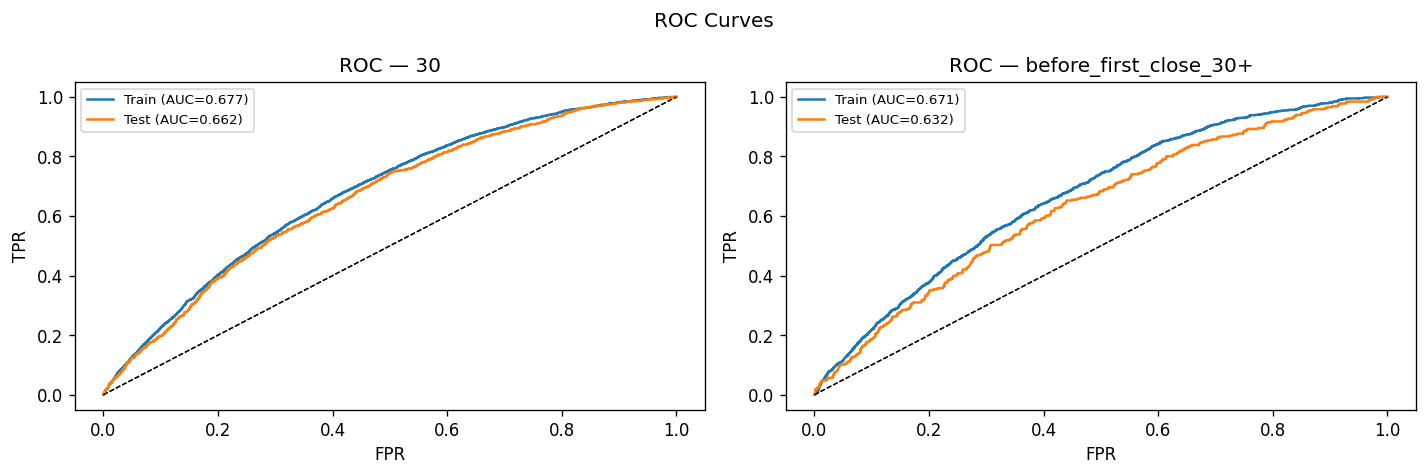

In [7]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(6*len(TARGETS), 4))
if len(TARGETS) == 1: axes = [axes]
for ax, target in zip(axes, TARGETS):
    res = results[target]
    metrics.plot_roc(res['y_train'], res['proba_train'], 'Train', ax)
    metrics.plot_roc(res['y_test'],  res['proba_test'],  'Test',  ax)
    ax.set_title(f'ROC — {target}')
plt.suptitle('ROC Curves'); plt.tight_layout(); plt.show()

## 5. Score тархалт (350–850)

Сайн (good) ба муу (bad) харилцагчдын оноо хэр зэрэг тусдаа тархаж байгаа нь моделийн ялгах чадварыг харуулна — хоорондоо их давхцах тусам ялгах чадвар сул.

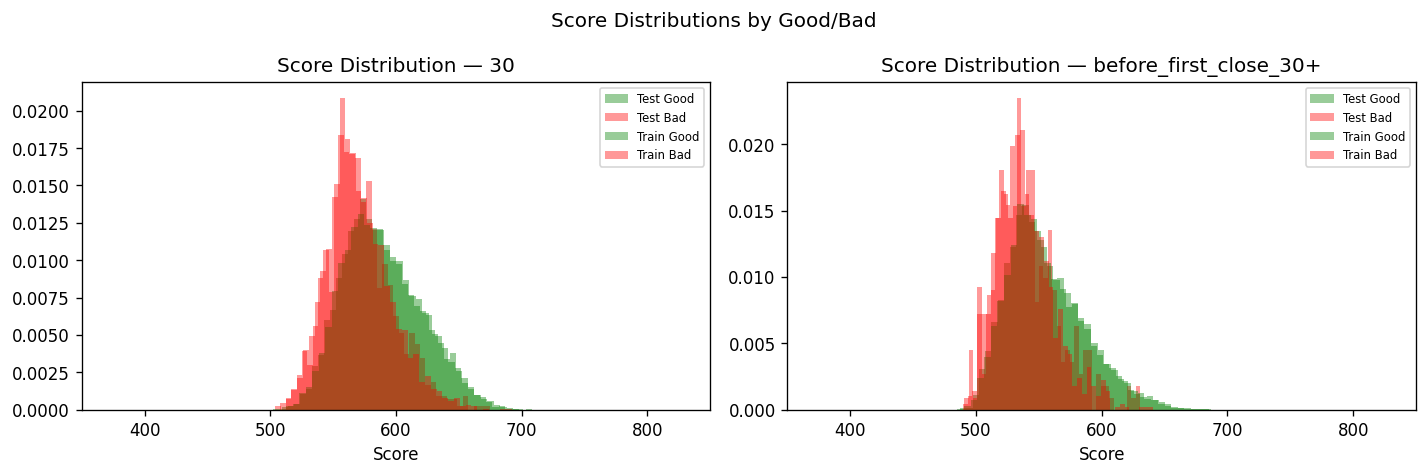

In [8]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(6*len(TARGETS), 4))
if len(TARGETS) == 1: axes = [axes]
for ax, target in zip(axes, TARGETS):
    res = results[target]
    metrics.plot_score_distribution(
        res['scores_train'], res['scores_test'],
        res['y_train'], res['y_test'], target, ax)
    ax.set_xlim(config.SCORE_MIN, config.SCORE_MAX)
plt.suptitle('Score Distributions by Good/Bad'); plt.tight_layout(); plt.show()

## 8. Оноо × bad rate ба хувьсагч × bad rate (шинжилгээ)

Эхнийх: TEST дээр оноо буурах тусам bad rate өсөж байгаа эсэх (модель зөв ажиллаж
байгаагийн шинж). Хоёр дахь: сонгосон топ хувьсагч бүрийн bin тус бүрийн bad rate
монотон өөрчлөгдөж байгаа эсэх.

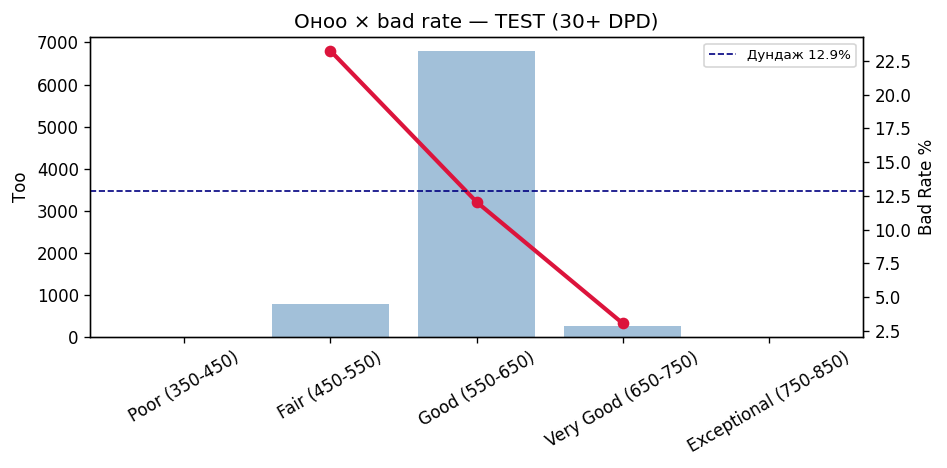

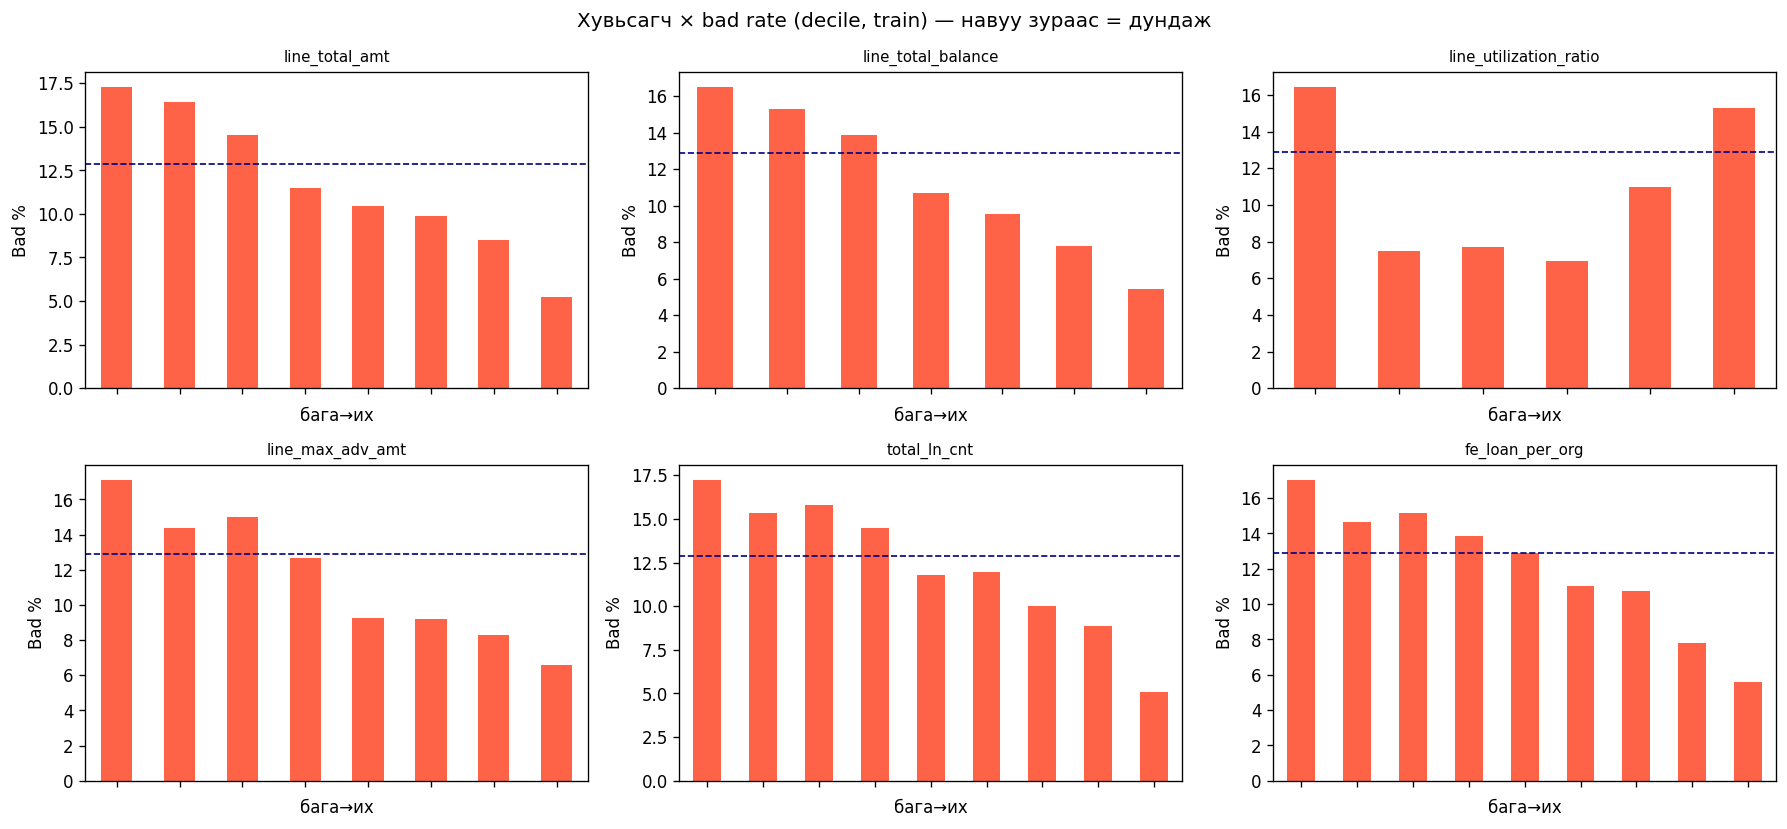

In [9]:
# (1) Оноо × bad rate — TEST
res = results[PRIMARY]
fig, ax = plt.subplots(figsize=(8, 4))
metrics.plot_badrate_by_band(res['scores_test'], res['y_test'], ax=ax)
ax.set_title('Оноо × bad rate — TEST (30+ DPD)')
plt.tight_layout(); plt.show()

# (2) Хувьсагч × bad rate (сонгосон топ 6, train)
iv_sel = pd.Series({c: iv.get(c, 0) for c in NUMERIC_VARS}).sort_values(ascending=False)
top6 = list(iv_sel.head(6).index)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.ravel(), top6):
    metrics.plot_feature_badrate(df_tr, feat, PRIMARY, ax)
plt.suptitle('Хувьсагч × bad rate (decile, train) — навуу зураас = дундаж')
plt.tight_layout(); plt.show()

## 6. Scorecard хүснэгт (Bin, WoE, Points)

Энэ бол моделийн 'зүрх' — хувьсагч бүрийн bin, WoE, оноо. Үүнийг production-д шууд хэрэгжүүлж болно. CSV болж хадгалагдана.

In [10]:
for target, res in results.items():
    sc = res['scorecard']
    print(f"\n{'='*70}\nSCORECARD TABLE — {target}\n{'='*70}")
    table = sc.table(style='summary')
    path = os.path.join(config.MODEL_DIR, f"scorecard_table_{safe_name(target)}.csv")
    table.to_csv(path, index=False)
    pd.set_option('display.max_rows', 200)
    print(table.head(40).to_string(index=False))
    print(f"\n... saved full table: {path}")


SCORECARD TABLE — 30
                  Variable                     Bin    Points
                       age           (-inf, 20.50)  1.227411
                       age          [20.50, 28.50) 20.217958
                       age          [28.50, 42.50) 16.641488
                       age            [42.50, inf)  3.920080
                       age                 Special 13.084390
                       age                 Missing 13.084390
           salary_last_amt       (-inf, 605555.50) 11.095243
           salary_last_amt [605555.50, 2819799.88) 16.191759
           salary_last_amt       [2819799.88, inf) 19.909522
           salary_last_amt                 Special 13.084390
           salary_last_amt                 Missing 13.084390
              salary_cv_6m           (-inf, -0.50) 15.140201
              salary_cv_6m           [-0.50, 0.02) 10.704948
              salary_cv_6m             [0.02, inf)  8.271095
              salary_cv_6m                 Special 13.084390
  

## 7. Feature importance (point range)

`Point Range = max(Points) − min(Points)`. Их range = өндөр нөлөө.

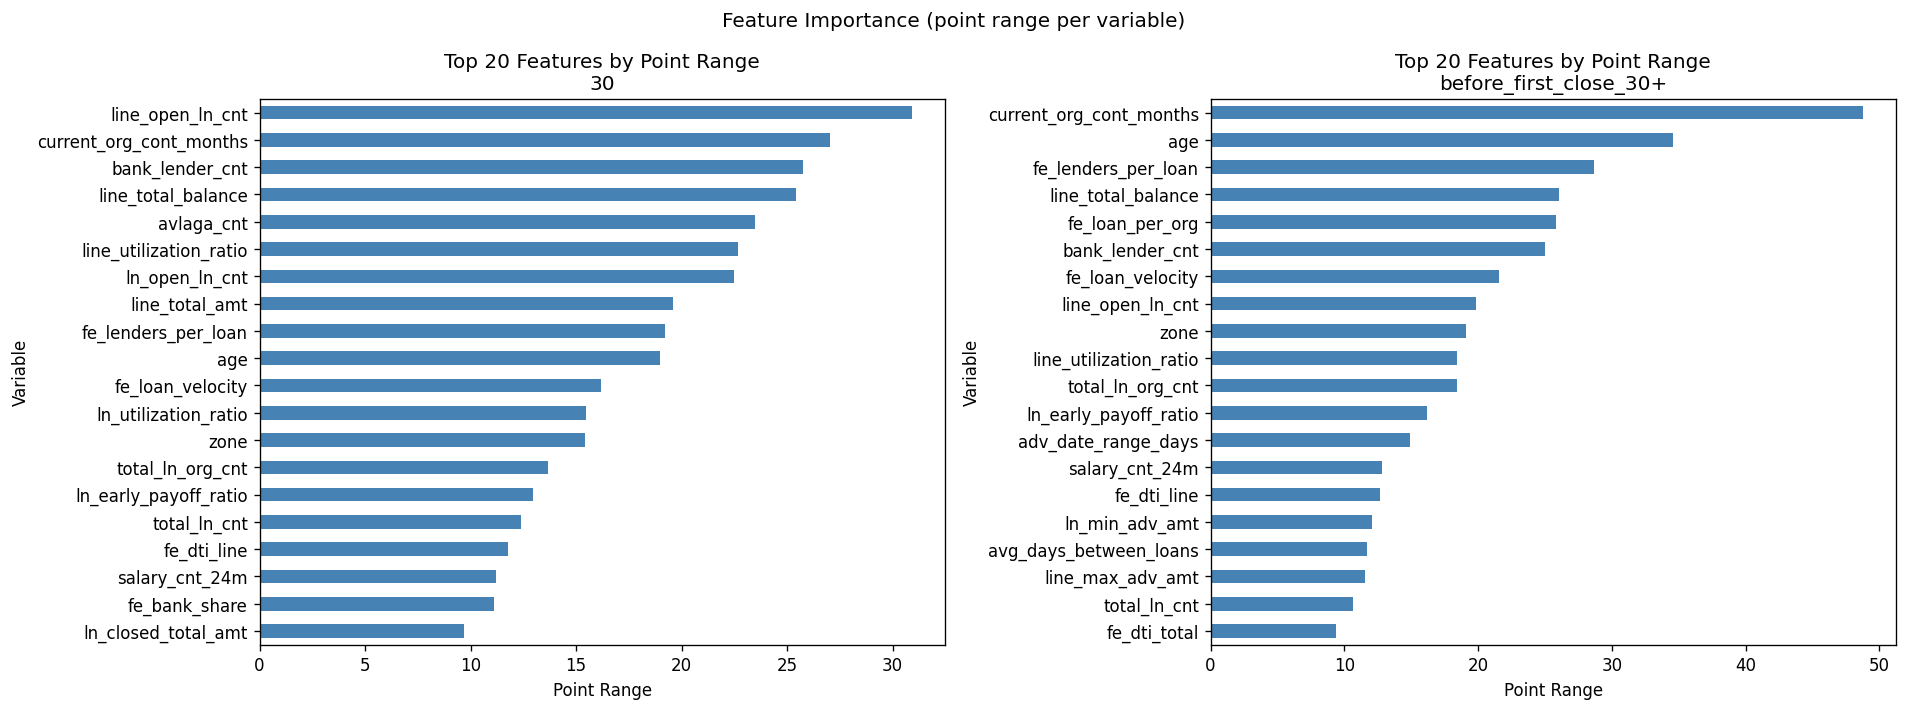

In [11]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(8*len(TARGETS), 6))
if len(TARGETS) == 1: axes = [axes]
for ax, target in zip(axes, TARGETS):
    table = results[target]['scorecard'].table(style='summary')
    fi = (table.groupby('Variable')['Points']
          .agg(lambda x: x.max()-x.min()).sort_values().tail(20))
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 Features by Point Range\n{target}')
    ax.set_xlabel('Point Range')
plt.suptitle('Feature Importance (point range per variable)')
plt.tight_layout(); plt.show()

## Дүгнэлт

- **Test гүйцэтгэл:** `30` таргет дээр AUC ≈ **0.672**, Gini ≈ 0.344, KS ≈ 0.262.
  Train↔Test зөрүү бага → overfit багатай, тогтвортой.
- **Давуу тал:** бүрэн ил тод, аудитад тайлбарлахад хялбар, шууд хэрэгжүүлэхэд бэлэн.
- **Хязгаар:** шугаман (linear) арга тул нарийн интеракцыг барьж чадахгүй —
  үүнийг 03/04 NB-ийн LightGBM нөхнө.
- **Анхаар:** цалингийн дутуу утга тусдаа bin болж эрсдэлийн дохио хадгалагдсан.

Бүрэн scorecard хүснэгт `models/scorecard_table_30.csv`-д хадгалагдсан.